####  B Vidakovic Quantum Framework for Wavelet Shrinkage 
## Example 8

### Thresholding [2, 1, 9, 0, 3, -10, 2, 4], normalized, lambda=0.4 

## Quantum Flagging as a Thresholding Surrogate

This notebook demonstrates a minimal **quantum analog of thresholding**, where a simple two-qubit circuit acts as a binary *flag* to detect coefficients exceeding a given magnitude threshold.

Each normalized coefficient $d_j$ is encoded into a qubit rotation via  
$\theta_j = \arccos(|d_j|)$, and a second qubit serves as an ancilla flag.  
When $|d_j| > \tau$, a controlled $X$ operation activates the flag qubit, and measurement of this ancilla yields a probability  
$P(\text{flag}=1)$ that approximates the indicator function $\mathbb{I}(|d_j| > \tau)$.

The experiment uses the **Qiskit AerSimulator** to execute the circuits for all coefficients and plot:
- the original normalized data, and  
- the corresponding quantum flag probabilities.

This forms a simple but illustrative example of **quantum coefficient selection**, showing how a nonlinear thresholding operation can be emulated probabilistically by circuit-based logic.

The generated figure (`anc_threshold.png` and `anc_threshold.pdf`) compares the original normalized signal and the probability that each coefficient is flagged as significant — a conceptual step toward **quantum wavelet shrinkage** through amplitude or ancilla-based mechanisms.


Normalized d: [ 0.263  0.158  1.     0.053  0.368 -1.     0.263  0.474]
value = +0.263,  |v|>0.4? -> P(flag=1) ≈ 0.00
value = +0.158,  |v|>0.4? -> P(flag=1) ≈ 0.00
value = +1.000,  |v|>0.4? -> P(flag=1) ≈ 1.00
value = +0.053,  |v|>0.4? -> P(flag=1) ≈ 0.00
value = +0.368,  |v|>0.4? -> P(flag=1) ≈ 0.00
value = -1.000,  |v|>0.4? -> P(flag=1) ≈ 1.00
value = +0.263,  |v|>0.4? -> P(flag=1) ≈ 0.00
value = +0.474,  |v|>0.4? -> P(flag=1) ≈ 1.00
Saved PNG: C:\Brani\MyJupyter\QThreshold\QwShrink\ex08anc_threshold.png 113102 bytes
Saved PDF: C:\Brani\MyJupyter\QThreshold\QwShrink\ex08anc_threshold.pdf 17549 bytes


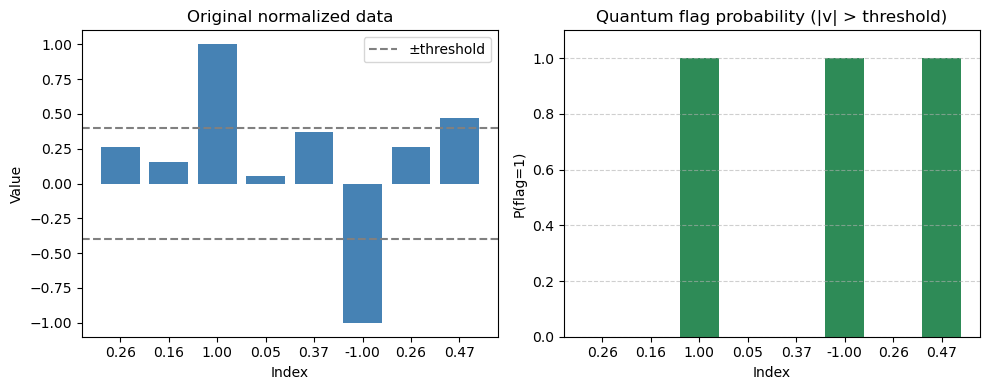

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import os
# ------------------------------
#  Data preparation
# ------------------------------
dd = np.array([2, 1, 9, 0, 3, -10, 2, 4], dtype=float)
d = 2 * (dd - dd.min()) / (dd.max() - dd.min()) - 1
print("Normalized d:", np.round(d, 3))

threshold = 0.4  # threshold on absolute value

backend = AerSimulator()

# ------------------------------
#  Quantum flag circuit
# ------------------------------
def flag_if_above_abs(value, threshold):
    qc = QuantumCircuit(2, 1)
    theta = np.arccos(abs(value))       # encode |value|
    qc.ry(theta, 0)
    if abs(value) > threshold:
        qc.x(1)                         # flag active if |value| > threshold
    qc.measure(1, 0)

    transpiled = transpile(qc, backend)
    job = backend.run(transpiled, shots=1024)
    counts = job.result().get_counts()
    p1 = counts.get("1", 0) / 1024
    return p1

# ------------------------------
#  Run circuit for all values
# ------------------------------
flags = [flag_if_above_abs(v, threshold) for v in d]

for v, p in zip(d, flags):
    print(f"value = {v:+.3f},  |v|>{threshold}? -> P(flag=1) ≈ {p:.2f}")

# ------------------------------
#  Plot original vs flagged data
# ------------------------------
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Left: original normalized data
ax[0].bar(range(len(d)), d, color="steelblue")
ax[0].axhline(threshold, color="gray", linestyle="--", label="±threshold")
ax[0].axhline(-threshold, color="gray", linestyle="--")
ax[0].set_xticks(range(len(d)))
ax[0].set_xticklabels([f"{v:.2f}" for v in d])
ax[0].set_title("Original normalized data")
ax[0].set_xlabel("Index")
ax[0].set_ylabel("Value")
ax[0].legend()

# Right: flag results (probability of flag=1)
ax[1].bar(range(len(d)), flags, color="seagreen")
ax[1].set_xticks(range(len(d)))
ax[1].set_xticklabels([f"{v:.2f}" for v in d])
ax[1].set_title("Quantum flag probability (|v| > threshold)")
ax[1].set_xlabel("Index")
ax[1].set_ylabel("P(flag=1)")
ax[1].set_ylim(0, 1.1)
ax[1].grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

# -------------------------------------------------
# (3) Save BEFORE show(), with opaque bg
# -------------------------------------------------
png_name = "ex08anc_threshold.png"
pdf_name = "ex08anc_threshold.pdf"

fig.savefig(
    png_name,
    dpi=300,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    bbox_inches="tight"
)

fig.savefig(
    pdf_name,
    dpi=300,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    bbox_inches="tight"
)

# optional: confirm file sizes are nonzero so you don't upload a blank file
print("Saved PNG:", os.path.abspath(png_name),
      os.path.getsize(png_name), "bytes")
print("Saved PDF:", os.path.abspath(pdf_name),
      os.path.getsize(pdf_name), "bytes")

plt.show()





